In [4]:
import sys 
!{sys.executable} -m pip install yfinance

  Using cached yfinance-1.4.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.0.6-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.0.6-py3-none-any.whl (146 kB)

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   -------- ------------------------------- 1/5 [multitasking]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------

In [1]:
import yfinance as yf
print("yfinance imported successfully")

yfinance imported successfully


In [3]:
#============================================
#STEP1: LOAD THE DATA
#============================================

#importing the finance data for brent and wti crude oil from yahoo finance
#this sets us up for model building in here
import yfinance as yf 
import pandas as pd 
import matplotlib.pyplot as plt

#download 10 years of brent crude oil price data 
#BZ=F is symbol for Brent Futures on yahoo finance
#Brent is the benchmark for global crude oil, while WTI is the benchmark for US crude oil
brent = yf.download('BZ=F', start='2015-01-01')

#download 10 years of WTI crude oil price data 
#CL=F is symbol for WTI Futures on yahoo finance
#wti is the benchmark for US crude oil, while brent is the benchmark for global crude oil
wti= yf.download('CL=F', start='2015-01-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [13]:
brent.columns
#checking for brent column names as we had a continual error in the formulas with syntax errors, turns out the column names were capitalized and not lowercase as I had been using in the formulas 


MultiIndex([( 'Close', 'BZ=F'),
            (  'High', 'BZ=F'),
            (   'Low', 'BZ=F'),
            (  'Open', 'BZ=F'),
            ('Volume', 'BZ=F')],
           names=['Price', 'Ticker'])

In [12]:
#============================================
#STEP2: CREATE SPREAD
#============================================

#Create a spread showing the difference in global oil (brent) and US oil (wti) prices
brent_Close=brent['Close']['BZ=F']
wti_Close=wti['Close']['CL=F']
spread=brent_Close - wti_Close
spread.head()
#this spread shows the difference in close price between the global oil index (brent) and the US oil index (wti) Over 10 years 
#EG on 02/01/2015, the spread was 3.73 meaning brent was trading above wti by 3.73 dollars per barrel

Date
2015-01-02    3.730000
2015-01-05    3.070000
2015-01-06    3.169998
2015-01-07    2.500000
2015-01-08    2.169998
dtype: float64

# Chart to show the Brent-WTI Spread (2015-Present)

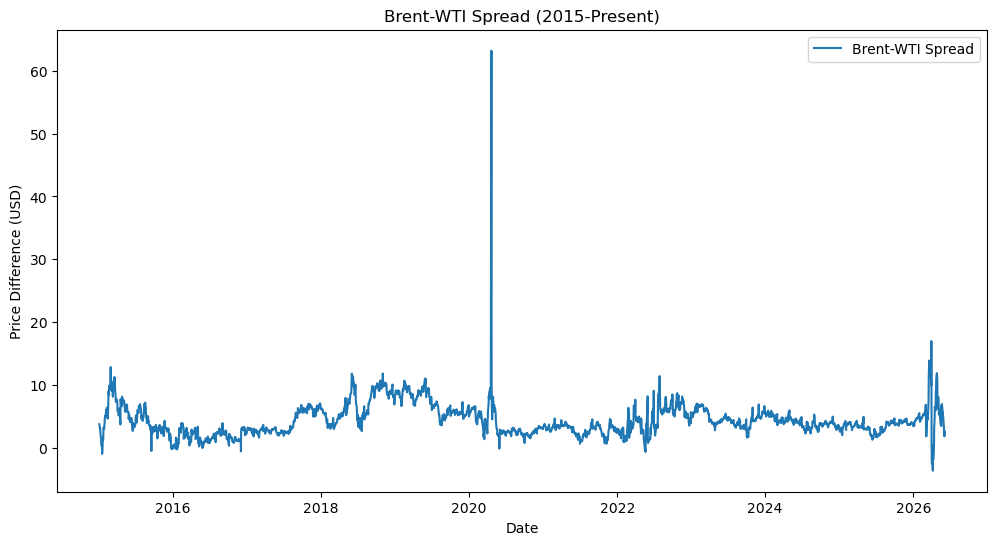

In [14]:
#============================================
#STEP 3: VISUALIZE THE SPREAD
#============================================

#creating a new blank chart canvas, width 12, height 6. 
plt.figure(figsize=(12,6))

#drawing the actual line on the chart for the spread between brent and wti
plt.plot(spread, label='Brent-WTI Spread')

#Adding title to the chart
plt.title('Brent-WTI Spread (2015-Present)')

#adding labels to the axis 
plt.xlabel('Date')
plt.ylabel('Price Difference (USD)')
#adding a legend to the chart to identify the line
plt.legend()
#displaying the chart
plt.show()

# Brent v WTI Spread analysis 
### Long Term Premium
- Brent crude consistently traded at premium to WTI across most of the sample period, reflecting the global nature of Brent pricing relative to the more regionally constrained US crude market.
### Volatility During Market Stress
- Periods of elavated spread volatility appear to coincide with the major market disruptions and macroeconomic shocks, particularly during Covid-19 pandemic in 2020. 
- Volatility shifts heading into 2026, due to the geopolitical impact of the war in the middle east. Iran controlling the Strait Of Hormuz, plays a vital part in world oil shipping.
### Supply & Logistics Effects
- Widening in the Brent-WTI spread may indicate regional supply imbalances, transportation bottlenecks, or differing demand conditions between international and US crude markets